**Predicting Bike Sharing Demand Using Machine
Learning and Temporal Features.**

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
import statsmodels.api as sm


In [3]:
Bike= pd.read_csv("hour.csv")


In [4]:
Bike.head()


,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


In [5]:
Bike.tail()


,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
17374,17375,2012-12-31,1,1,12,19,0,1,1,2,0.26,0.2576,0.60,0.1642,11,108,119
17375,17376,2012-12-31,1,1,12,20,0,1,1,2,0.26,0.2576,0.60,0.1642,8,81,89
17376,17377,2012-12-31,1,1,12,21,0,1,1,1,0.26,0.2576,0.60,0.1642,7,83,90
17377,17378,2012-12-31,1,1,12,22,0,1,1,1,0.26,0.2727,0.56,0.1343,13,48,61
17378,17379,2012-12-31,1,1,12,23,0,1,1,1,0.26,0.2727,0.65,0.1343,12,37,49


In [6]:
Bike.shape   # rows, columns


(17379, 17)

In [7]:
Bike.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  object 
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), object(1)
memory usage: 2.3+ MB


In [8]:
Bike.dtypes


,0
instant,int64
dteday,object
season,int64
yr,int64
mnth,int64
hr,int64
holiday,int64
weekday,int64
workingday,int64
weathersit,int64


In [9]:
Bike.columns


Index(['instant', 'dteday', 'season', 'yr', 'mnth', 'hr', 'holiday', 'weekday',
       'workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed',
       'casual', 'registered', 'cnt'],
      dtype='object')

In [10]:
Bike.describe()


,instant,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,17379.0000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
mean,8690.0000,2.501640,0.502561,6.537775,11.546752,0.028770,3.003683,0.682721,1.425283,0.496987,0.475775,0.627229,0.190098,35.676218,153.786869,189.463088
std,5017.0295,1.106918,0.500008,3.438776,6.914405,0.167165,2.005771,0.465431,0.639357,0.192556,0.171850,0.192930,0.122340,49.305030,151.357286,181.387599
min,1.0000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,4345.5000,2.000000,0.000000,4.000000,6.000000,0.000000,1.000000,0.000000,1.000000,0.340000,0.333300,0.480000,0.104500,4.000000,34.000000,40.000000
50%,8690.0000,3.000000,1.000000,7.000000,12.000000,0.000000,3.000000,1.000000,1.000000,0.500000,0.484800,0.630000,0.194000,17.000000,115.000000,142.000000
75%,13034.5000,3.000000,1.000000,10.000000,18.000000,0.000000,5.000000,1.000000,2.000000,0.660000,0.621200,0.780000,0.253700,48.000000,220.000000,281.000000
max,17379.0000,4.000000,1.000000,12.000000,23.000000,1.000000,6.000000,1.000000,4.000000,1.000000,1.000000,1.000000,0.850700,367.000000,886.000000,977.000000


In [11]:
Bike.isnull().sum()


,0
instant,0
dteday,0
season,0
yr,0
mnth,0
hr,0
holiday,0
weekday,0
workingday,0
weathersit,0


In [12]:
Bike.duplicated().sum()


np.int64(0)

In [13]:
Bike['cnt'].describe()


,cnt
count,17379.000000
mean,189.463088
std,181.387599
min,1.000000
25%,40.000000
50%,142.000000
75%,281.000000
max,977.000000


## **Distribution plot**

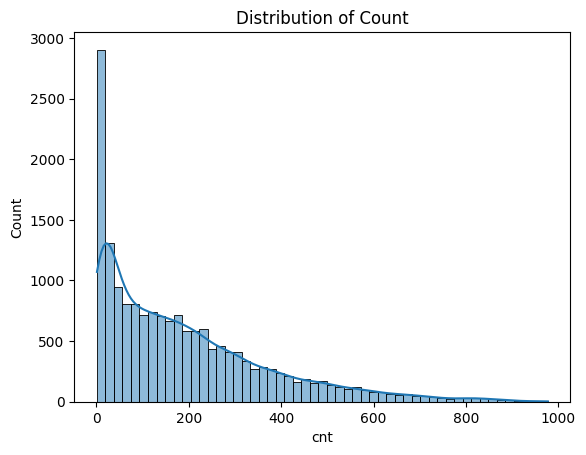

In [14]:
# Histogram of cnt
plt.figure()
sns.histplot(Bike['cnt'], kde=True)
plt.title("Distribution of Count")
plt.show()


## **Frequency counts**

In [15]:
#Counts number of rows in each season category
Bike['season'].value_counts()



,count
season,
3,4496
2,4409
1,4242
4,4232


In [16]:
#Counts rows per weather situation category.
Bike['weathersit'].value_counts()


,count
weathersit,
1,11413
2,4544
3,1419
4,3


In [17]:
#Counts rows per weekday category.
Bike['weekday'].value_counts()

,count
weekday,
6,2512
0,2502
5,2487
1,2479
3,2475
4,2471
2,2453


### **Count plot for season**

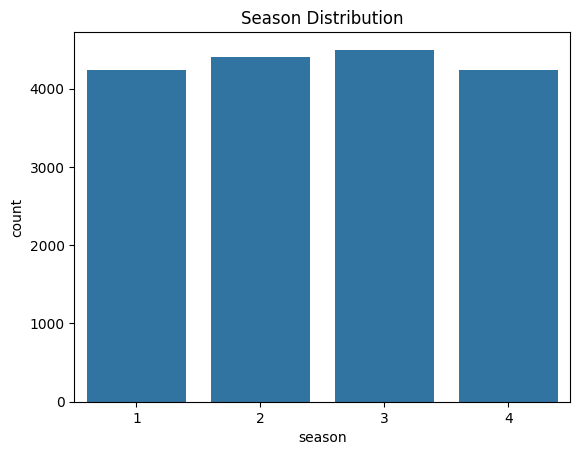

In [18]:
#Bar chart of how many observations for each season.
plt.figure()
sns.countplot(x='season', data=Bike)
plt.title("Season Distribution")
plt.show()


In [19]:
corr = Bike.drop('dteday', axis=1).corr()

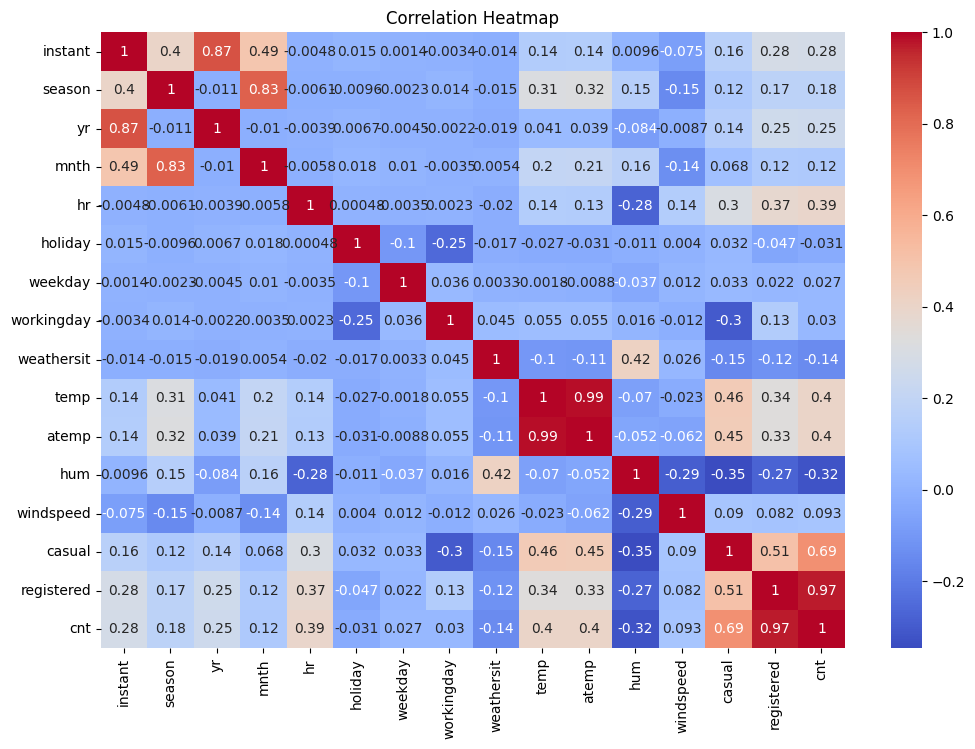

In [20]:
plt.figure(figsize=(12,8))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()


## **scatter plot**


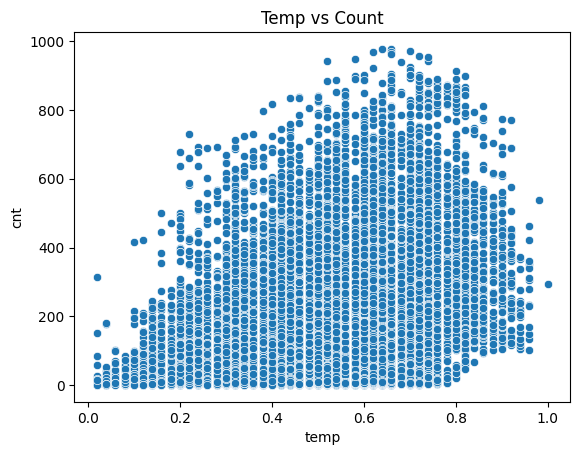

In [21]:
 plt.figure()
sns.scatterplot(x='temp', y='cnt', data=Bike)
plt.title("Temp vs Count")
plt.show()


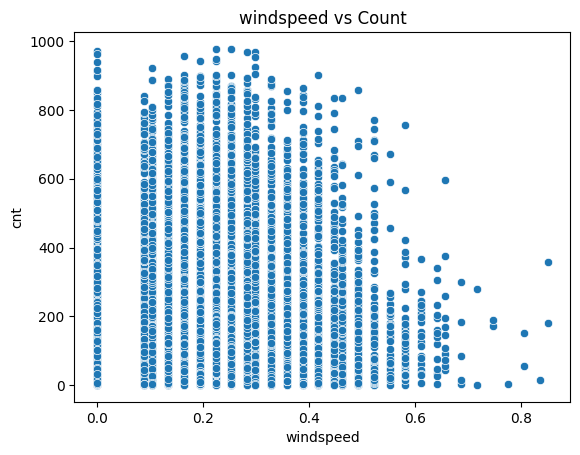

In [22]:
plt.figure()
sns.scatterplot(x='windspeed', y='cnt', data=Bike)
plt.title("windspeed vs Count")
plt.show()

In [23]:
#plt.figure()
#sns.boxplot(x='season', y='cnt', data=Bike)
#plt.title("Season vs Count")
#plt.show()


In [24]:
Bike.drop(columns=['instant'], inplace=True)


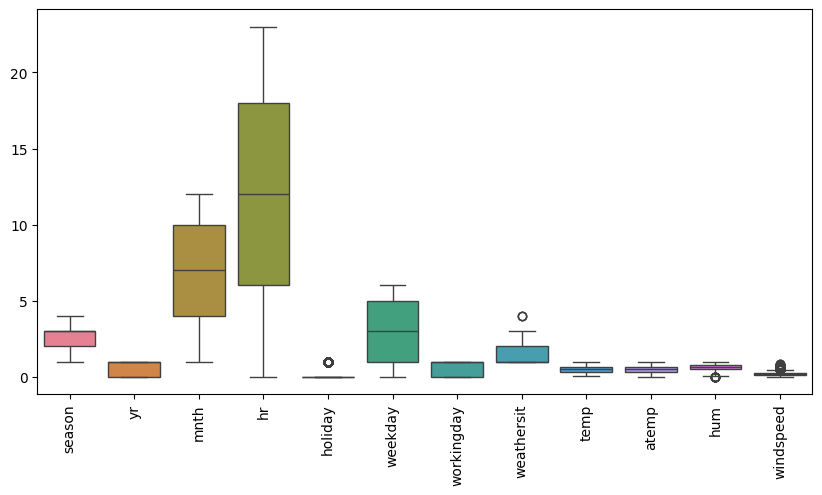

In [25]:
num_cols = Bike.select_dtypes(include=np.number).columns
plt.figure(figsize=(10,5))
sns.boxplot(data=Bike[['season', 'yr', 'mnth', 'hr', 'holiday', 'weekday',
       'workingday', 'weathersit', 'temp','atemp','hum','windspeed']])
plt.xticks(rotation=90)
plt.show()

In [26]:
Q1 = Bike['cnt'].quantile(0.25)
Q3 = Bike['cnt'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
print("Lower bound:", lower)
print("Upper bound:", upper)

#

Lower bound: -321.5
Upper bound: 642.5


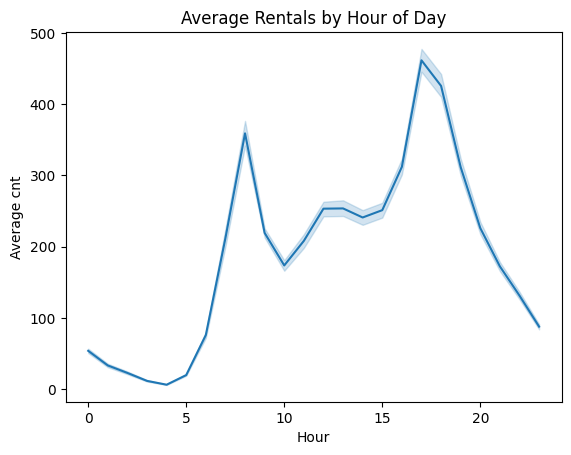

In [27]:
# Rentals by weekday
plt.figure()
sns.lineplot(x="hr", y="cnt", data=Bike, estimator="mean")
plt.title("Average Rentals by Hour of Day")
plt.xlabel("Hour")
plt.ylabel("Average cnt")
plt.show()

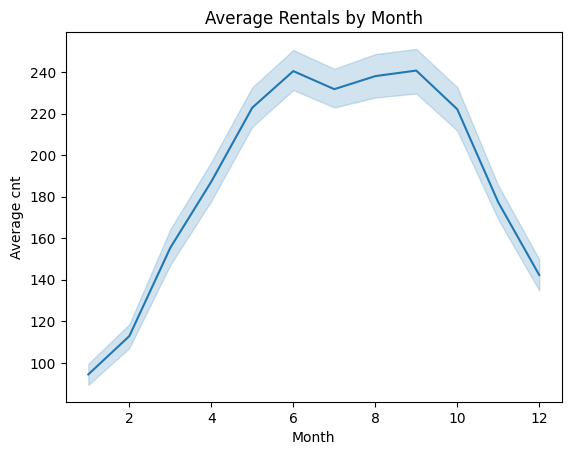

In [28]:

# Rentals by month
plt.figure()
sns.lineplot(x="mnth", y="cnt", data=Bike, estimator="mean")
plt.title("Average Rentals by Month")
plt.xlabel("Month")
plt.ylabel("Average cnt")
plt.show()


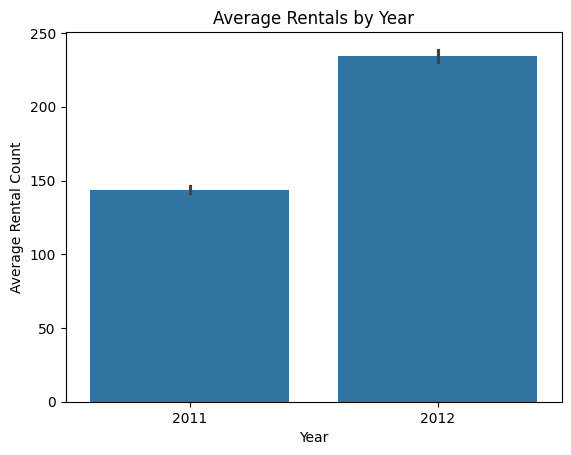

In [29]:
Bike["year_label"] = Bike["yr"].map({0: "2011", 1: "2012"})

plt.figure()
sns.barplot(x="year_label", y="cnt", data=Bike, estimator="mean")
plt.title("Average Rentals by Year")
plt.xlabel("Year")
plt.ylabel("Average Rental Count")
plt.show()


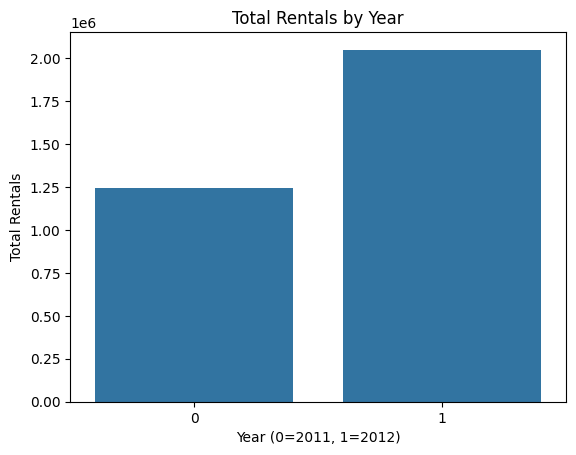

In [30]:
yearly = Bike.groupby("yr")["cnt"].sum().reset_index()

plt.figure()
sns.barplot(x="yr", y="cnt", data=yearly)
plt.title("Total Rentals by Year")
plt.xlabel("Year (0=2011, 1=2012)")
plt.ylabel("Total Rentals")
plt.show()


In [31]:
# Convert date
Bike["dteday"] = pd.to_datetime(Bike["dteday"])

# Sort by time
Bike = Bike.sort_values(["dteday", "hr"]).reset_index(drop=True)


In [32]:
# ==========================================
#  RANDOM FOREST
# ==========================================

Bike1 = Bike.copy()

Bike1 = Bike1.drop(columns=["casual", "registered", "instant"], errors="ignore")

Bike1["hr_sin"] = np.sin(2 * np.pi * Bike1["hr"] / 24)
Bike1["hr_cos"] = np.cos(2 * np.pi * Bike1["hr"] / 24)

Bike1["mnth_sin"] = np.sin(2 * np.pi * Bike1["mnth"] / 12)
Bike1["mnth_cos"] = np.cos(2 * np.pi * Bike1["mnth"] / 12)

Bike1 = pd.get_dummies(Bike1, columns=["season", "weathersit", "weekday"], drop_first=True)

# Sort by time
Bike1 = Bike1.sort_values(["dteday", "hr"]).reset_index(drop=True)

# 80-20 split
split_index = int(len(Bike1) * 0.8)

train = Bike1.iloc[:split_index]
test  = Bike1.iloc[split_index:]

X_train = train.drop(columns=["cnt", "dteday"])
y_train = train["cnt"]

X_test = test.drop(columns=["cnt", "dteday"])
y_test = test["cnt"]

rf = RandomForestRegressor(random_state=42)
rf.fit(X_train, y_train)

pred_rf = rf.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, pred_rf))
mae  = mean_absolute_error(y_test, pred_rf)
r2   = r2_score(y_test, pred_rf)
mape = np.mean(np.abs((y_test - pred_rf) / np.maximum(y_test, 1))) * 100

print("Random Forest Results (80-20 Split)")
print("RMSE:", rmse)
print("MAE :", mae)
print("R2  :", r2)
print("MAPE:", mape)

Random Forest Results (80-20 Split)
RMSE: 81.32791780186466
MAE : 53.929730581127735
R2  : 0.8639426745720916
MAPE: 35.711469262502874


In [33]:
# ==========================================
# XGBOOST
# ==========================================

xgb_df = Bike.copy()

# Create full datetime
xgb_df["datetime"] = xgb_df["dteday"] + pd.to_timedelta(xgb_df["hr"], unit="h")
xgb_df = xgb_df.sort_values("datetime").reset_index(drop=True)

# Remove leakage and the problematic 'year_label' column
xgb_df = xgb_df.drop(columns=["casual", "registered", "instant", "year_label"], errors="ignore")

# Lag features
xgb_df["lag_1"] = xgb_df["cnt"].shift(1)
xgb_df["lag_24"] = xgb_df["cnt"].shift(24)
xgb_df["lag_168"] = xgb_df["cnt"].shift(168)

xgb_df = xgb_df.dropna().reset_index(drop=True)

# Cyclical encoding
xgb_df["hr_sin"] = np.sin(2 * np.pi * xgb_df["hr"] / 24)
xgb_df["hr_cos"] = np.cos(2 * np.pi * xgb_df["hr"] / 24)

# One-hot encoding
xgb_df = pd.get_dummies(xgb_df, columns=["season", "weathersit", "weekday"], drop_first=True)

# 80-20 split
split_index = int(len(xgb_df) * 0.8)

train = xgb_df.iloc[:split_index]
test  = xgb_df.iloc[split_index:]

X_train = train.drop(columns=["cnt", "dteday", "datetime"])
y_train = train["cnt"]

X_test = test.drop(columns=["cnt", "dteday", "datetime"])
y_test = test["cnt"]

xgb = XGBRegressor(
    n_estimators=800,
    learning_rate=0.05,
    max_depth=7,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    objective="reg:squarederror"
)

xgb.fit(X_train, y_train)
pred_xgb = xgb.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, pred_xgb))
mae  = mean_absolute_error(y_test, pred_xgb)
r2   = r2_score(y_test, pred_xgb)
mape = np.mean(np.abs((y_test - pred_xgb) / np.maximum(y_test, 1))) * 100

print("XGBoost (80-20)")
print("RMSE:", rmse)
print("MAE :", mae)
print("R2  :", r2)
print("MAPE:", mape)


XGBoost (80-20)
RMSE: 46.97731541991837
MAE : 29.102014541625977
R2  : 0.9543332457542419
MAPE: 25.47437870704935


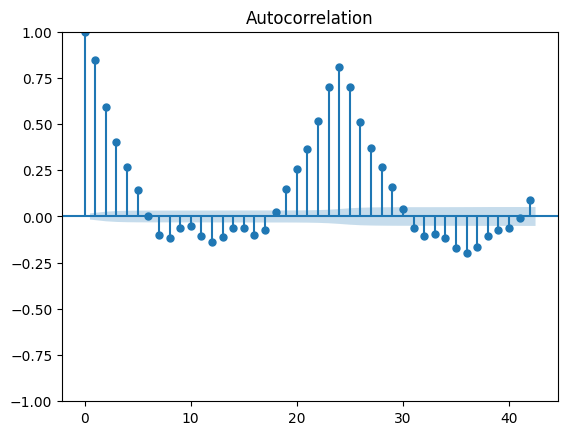

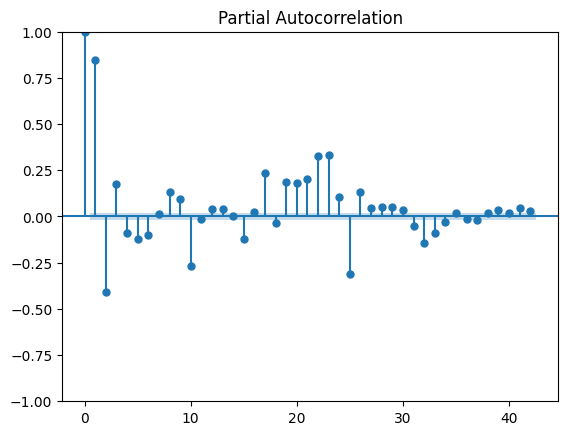

In [34]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf


plot_acf(y_train) #q
plt.show()

plot_pacf(y_train) #p
plt.show()

In [35]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(y_train)
print(result[1])  # p -value

3.378447439942454e-08


In [36]:
# ==========================================
# SARIMAX
# ==========================================

sar_df = Bike.copy()

# Remove leakage
sar_df = sar_df.drop(columns=["casual", "registered", "instant"], errors="ignore")

# Cyclical encoding
sar_df["hr_sin"] = np.sin(2 * np.pi * sar_df["hr"] / 24)
sar_df["hr_cos"] = np.cos(2 * np.pi * sar_df["hr"] / 24)

sar_df["mnth_sin"] = np.sin(2 * np.pi * sar_df["mnth"] / 12)
sar_df["mnth_cos"] = np.cos(2 * np.pi * sar_df["mnth"] / 12)

# One-hot encoding
sar_df = pd.get_dummies(sar_df, columns=["season", "weathersit", "weekday"], drop_first=True)

# Sort by time
sar_df = sar_df.sort_values(["dteday", "hr"]).reset_index(drop=True)

# 80-20 split
split_index = int(len(sar_df) * 0.8)

train = sar_df.iloc[:split_index]
test  = sar_df.iloc[split_index:]

X_train = train.drop(columns=["cnt", "dteday"]).astype(float)
y_train = train["cnt"].astype(float)

X_test = test.drop(columns=["cnt", "dteday"]).astype(float)
y_test = test["cnt"].astype(float)

# Add constant
X_train_sm = sm.add_constant(X_train, has_constant="add")
X_test_sm  = sm.add_constant(X_test, has_constant="add")

X_test_sm = X_test_sm.reindex(columns=X_train_sm.columns, fill_value=0)

model = sm.tsa.statespace.SARIMAX(
    y_train,
    exog=X_train_sm,
    order=(1,0,1),
    seasonal_order=(1,0,1,24),
    enforce_stationarity=False,
    enforce_invertibility=False
)

fit = model.fit(disp=False)

forecast = fit.get_forecast(steps=len(y_test), exog=X_test_sm)
pred_sarimax = forecast.predicted_mean

rmse = np.sqrt(mean_squared_error(y_test, pred_sarimax))
mae  = mean_absolute_error(y_test, pred_sarimax)
r2   = r2_score(y_test, pred_sarimax)
mape = np.mean(np.abs((y_test - pred_sarimax) / np.maximum(y_test, 1))) * 100

print("SARIMAX (80-20)")
print("RMSE:", rmse)
print("MAE :", mae)
print("R2  :", r2)
print("MAPE:", mape)

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


SARIMAX (80-20)
RMSE: 157.97399710766388
MAE : 119.6768753906292
R2  : 0.48664968064488934
MAPE: 311.4794653471363


In [37]:
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor


# ==========================================
# RANDOM FOREST TUNING
# ==========================================

rf_df = Bike.copy()

rf_df = rf_df.drop(columns=["casual", "registered", "instant"], errors="ignore")

rf_df["hr_sin"] = np.sin(2 * np.pi * rf_df["hr"] / 24)
rf_df["hr_cos"] = np.cos(2 * np.pi * rf_df["hr"] / 24)
rf_df["mnth_sin"] = np.sin(2 * np.pi * rf_df["mnth"] / 12)
rf_df["mnth_cos"] = np.cos(2 * np.pi * rf_df["mnth"] / 12)

rf_df = pd.get_dummies(rf_df, columns=["season", "weathersit", "weekday"], drop_first=True)

rf_df = rf_df.sort_values(["dteday", "hr"]).reset_index(drop=True)

split_index = int(len(rf_df) * 0.8)
train = rf_df.iloc[:split_index]
test  = rf_df.iloc[split_index:]

X_train = train.drop(columns=["cnt", "dteday"])
y_train = train["cnt"]

X_test = test.drop(columns=["cnt", "dteday"])
y_test = test["cnt"]

tscv = TimeSeriesSplit(n_splits=5)

rf = RandomForestRegressor(random_state=42, n_jobs=-1)

rf_param_grid = {
    "n_estimators": [100, 200, 300, 500],
    "max_depth": [10, 15, 20, 25, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2", None]
}

rf_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=rf_param_grid,
    n_iter=20,
    cv=tscv,
    scoring="neg_root_mean_squared_error",
    verbose=1,
    random_state=42,
    n_jobs=-1
)

rf_search.fit(X_train, y_train)

best_rf = rf_search.best_estimator_
pred_rf_tuned = best_rf.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, pred_rf_tuned))
mae  = mean_absolute_error(y_test, pred_rf_tuned)
r2   = r2_score(y_test, pred_rf_tuned)
mape = np.mean(np.abs((y_test - pred_rf_tuned) / np.maximum(y_test, 1))) * 100

print("Best RF Params:", rf_search.best_params_)
print("Tuned Random Forest Results")
print("RMSE:", rmse)
print("MAE :", mae)
print("R2  :", r2)
print("MAPE:", mape)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best RF Params: {'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': None, 'max_depth': 25}
Tuned Random Forest Results
RMSE: 80.66840195217172
MAE : 53.511763552791024
R2  : 0.8661403978494862
MAPE: 35.413360001157805
